# Matplotlib - Pie Plots
___
- EG: `plt.pie()`
- Moving onto Pie Charts, while they are pretty good at showing some things (where there are only 2 options to compare), other things where there are more Variables involved, they are useless
- Here, we will be looking at how to Plot Pie Charts and also, when would be the best times/Scenarios to use these Visuals

In [1]:
# Imports
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

- Now it's time to start Plotting one of these Columns!
- Let's start with `job_work_from_home` because it's a Boolean Expression and we are either going to have a **True** or **False** Value
    - With this, we are only Comparing 2 things... which is really great for Pie Charts!
- Starting off:
    - Specify the Data Frame we are using: `df[]`
    - Pass in the Column we want to Plot on a Pie Chart: `'job_work_from_home'`
    - Now we want to get the Counts of the different Values in this Column, so we Run the `.value_counts()` Method
    - Now that we have this, we can Plot these Values on a Pie Chart
    - To do this, Run the `.plot()` Method
    - Passing in the kind as always, this time because we want a Pie we use: `kind='pie'`

<Axes: >

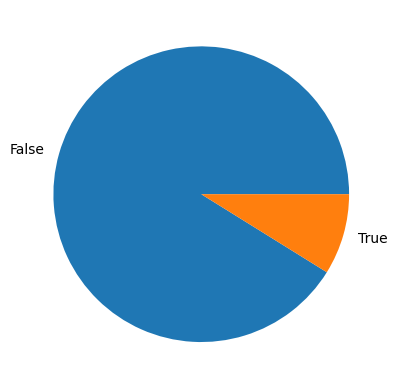

In [ ]:
# Creating a Pie Plot for the job_work_from_home Column
df['job_work_from_home'].value_counts().plot(kind='pie')

- We get our Pie Chart back! Buuuut it does need some Cleanup because it's pretty Basic and it's lacking a bit of information
    - What are we comparing True to False for?
    - What is the Title?
- Doing this Cleanup as follows:
    - Specifying the Title by using the: `plt.title()` Method and Passing in the String we want to use to Name our Visual
    - Also, getting rid of that Memory Location Label, as always, Running the: `plt.show()` Method

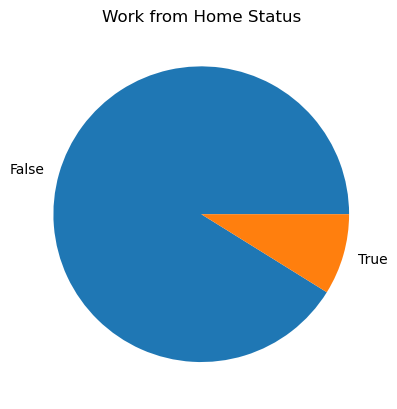

In [6]:
# Pie Chart with all the Cleanup
df['job_work_from_home'].value_counts().plot(kind='pie')
plt.title('Work from Home Status')
plt.show()

- This is much better at showing the Work From Home Status and we are comparing the 2 Values!
    - Looking at this, it's an overwhelming Majority of False Values for the Requirement to Work From Home
- This is actually a really good Pie Chart to use!
- Because we have a really good one... tt's time to show a really bad one as a Comparison...
    - Taking the same Code as above but just Changing the Column we are Displaying
        - Instead of `job_work_from_home`, we will use `job_title_short`

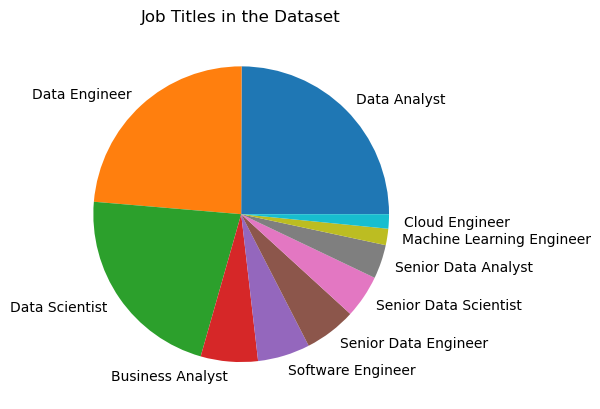

In [19]:
# Making a really bad Pie Chart with the job_title_short Column
df['job_title_short'].value_counts().plot(kind='pie')
plt.title('Job Titles in the Dataset')
plt.show()

- Looking at this... it's not great... because it's hard to Compare the differences between the different Jobs and it's kind of hard to read
- When looking at this for Data Analyst, Scientist and Engineer, it's very difficult to determine, which one is actually higher...
- Comparing this Data on a Pie Plot against a Horizontal Bar Chart showing the exact same Data...

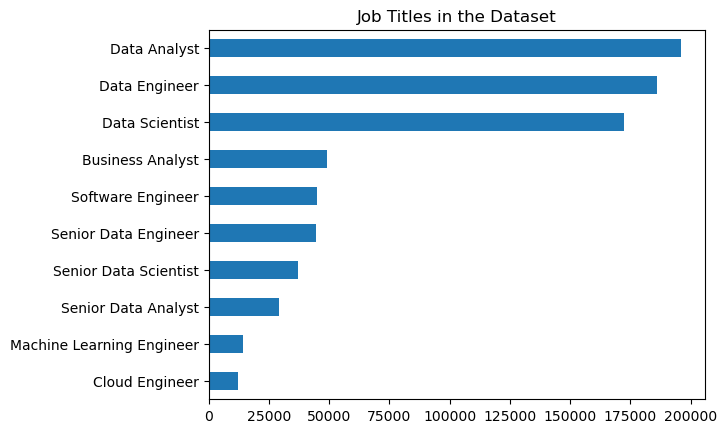

In [20]:
# Creating a Horizontal Bar Chart using the same Data as comparison
df['job_title_short'].value_counts().plot(kind='barh')
plt.title('Job Titles in the Dataset')
plt.gca().invert_yaxis()
plt.ylabel('')
plt.show()

- We can clearly see that Data Analyst outpaces, Engineers, which outpaces Scientist
- We can see this much better and clearer especially with how many Values there are here
- The point of this is, we need to be very careful when using these Pie Charts that we are using them on the correct thing
    - If there are more than 2 things, it's time to question it and more than likely, a Bar Chart should be used instead...

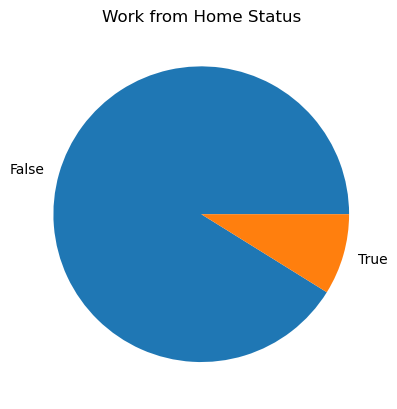

In [24]:
# Showing the original Pie Chart again
df['job_work_from_home'].value_counts().plot(kind='pie')
plt.title('Work from Home Status')
plt.show()

- Getting back to the Original Pie Chart, there's 2 things that need to be Customized
    - First: The Starting Angle of the Pie Chart and where the Smaller Slice is actually placed
- Usually, when looking at a Pie Chart, the eye gravitates towards the Top Centre Portion of it
    - So it makes sense to orientate the Chart, so that the True Values are up at the Top
    - We can do this, by Passing in the Parameter `startangle=` into the `.plot()` Method
    - Setting it to 90, because we want the Start of it to be at the 90 Degree mark 

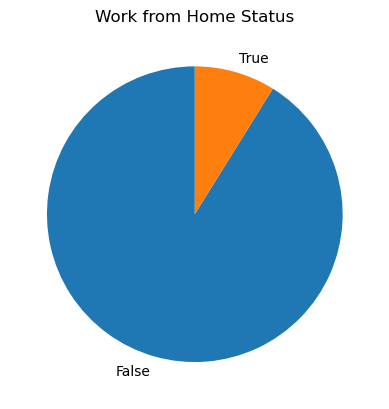

In [25]:
# Setting the Starting Angle to 90 Degrees
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90)
plt.title('Work from Home Status')
plt.show()

- This is now much better and exactly the orientation of what we want
    - Changing the Value of 90 to 180, it will put the True Slice all the way to the Left, because the Reference point is all the way over on the Right because that's where 0 originally is
- The other thing that would be good to Display on here would be the Percentages outlining what the True and False Values are
    - The way to do this would be:
        - Passing in the Parameter `autopct=` inside of the `.plot()` Method. This stands for Auto Percentage
        - Setting this to `'%1f'`
        - To see all the accepted Values check the [Documentation]('https://docs.python.org/3/library/string.html')
            - Underneath the String Section, it goes into Detail on all the different Special Cahracters that can be used to Format a String
            - Quick Crash course is: 
                - `%` introduces that we are giong to be Formatting the Text from here
                - `1` is the Minimum Width of the Number. It can be 1 or more. If Decimal Places are wanted we can put `1.1` which will Return to 1 Decimal place
                - `f` specifies that this is a Floating Point Number
                - `%%` last thing to add and it's special to this to add 2 of them. This is so it actually makes it the Floating Point Number
        - This will Return, the associated Percentage for each of the Slices
            - True is a 8.9%
            - False is a 91.1%

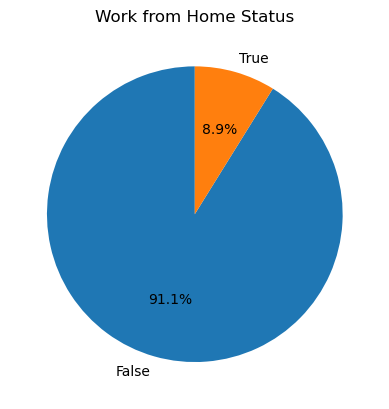

In [28]:
# Displaying the Percentage Values associated to each slice
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.title('Work from Home Status')
plt.show()

- Now that it's Formatted correctly with the appropriate Title and all the different Labels alongside having the correct Orientation
    - It's looking pretty good! And overall it's impressive
- Now it's time to take it up a Notch!
    - Inside of the DataFrame, we have 3 different Columns that provide Boolean Values for the different Job Postings
        - Those Columns are `job_work_from_home`, `job_no_degree_mention` and `job_health_insurance`
    - Now it's time to use our Knowledge of Subplots and actually Plot all these different Pie Charts onto **1 Single Plot**
        - Start by Defining our `fig` and `ax` Tuple Variables alongside our `.subplots()` Method
        - Starting simple first, by Creating/Plotting 1 and then Building on more using a `for` Loop
        - Plotting the `job_work_from_home` first using the Matplotlib way of Plotting this
            - Calling `ax` first and then invoking the `.pie()` Function
            - Passing in the `df['job_work_from_home']` inside the `.pie()` Function
            - Then using the `.value_counts()` on the `'job_work_from_home'` Column
            - Printing it out below using the `.show()` Function to make sure it's working

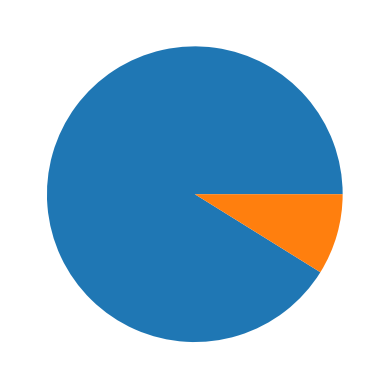

In [30]:
# Creating a Pie Plot using the Matplotlib way
fig, ax = plt.subplots()

ax.pie(df['job_work_from_home'].value_counts())

plt.show()

- It's pretty ugly... but least we know it's working and it's Displaying as expected
- Now we are using, Matplotlib nomanclature to Create this rather than the built in Plot Method of Pandas
- Because we have 3 different Pie Charts, we will want to use a Loop for this! Because we don't want to have to go through and write the same Code, 3 different times... it's too cunmbersome
- To do this we will:
    - Define a Dictionary called `dict_column`
    - For the **Key** call out the DataFrame Column name itself of: `job_work_from_home` and then for the **Value**, Provide what you want as the Header on the Pie Chart: `'Work From Home'`
        - Do this for all 3: `'job_work_from_home': 'Work From Home'`, `'job_no_degree_mention': 'Job Degree Req.'`, `'job_health_insurance': 'Health Insurance Offered'`
    - Because we are going to have 3 different Pie Charts, we will need to Update our `.subplots()` rows and columns Values to reflect that
        - Because we want them all side by side, we will need 1 row and 3 columns
    - Now for the `for` loop
        - Start by specifying the `for` Keyword
        - Then the iterable Variable's we are going to use
            - For what we are going to be getting back while we are enumerating this Dict Column of Items...
            - We are going to be getting our **Index** of `i`
            - We are also going to be getting a **Tuple** back so we need to specify `()`
                - Inside here, we pass in `column`, because we specified Column on the Dictionary first, and that's the **Key**
                - And then the `title`, because we specified the title on the Dictionary second, and that's the **Values**
        - Because we are looking into the Dictionary, we will use the Keyword `in`
        - And because we are using a Dictionary and need to Cycle through the Items of it, we specify `dict_column` since it's the Dictionary Name and invoke the `.items()` Method
        - We then Wrap this in the `.enumerate()` Function because we want to Run this on it
            - Because when we Run `.enumerate()` on a List, it provides back an **Index** and we will need to use that Index and Provide it for the `ax`, so it knows where to Plot the Pie Chart
            - We will also need to Update the `.pie()` Function as it's really messy and ugly right now, but we will get to that!
            - Instead of Plotting something, we will first off, show all these Values to see what we are Plotting and for Visibility of Understanding what is going on in the Loop
            - It's just easier to follow along and see what is happening in here
            - To do this, we will `print(i, column, title)`. This will loop through and Print out all the different Values that are contained in those Variables        

0 job_work_from_home Work From Home
1 job_no_degree_mention Job Degree Req.
2 job_health_insurance Health Insurance Offered


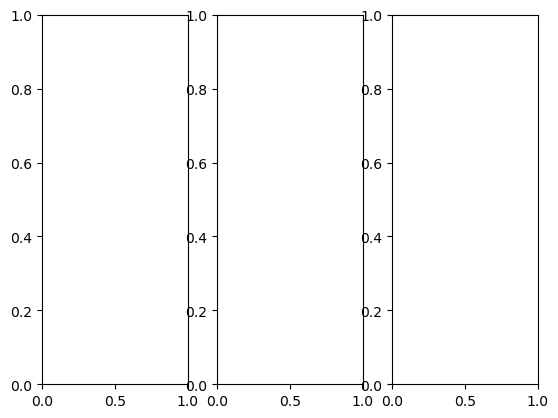

In [31]:
# Creating the For Loop
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    print(i, column, title)

- What this is doing is Iterating through all the Items in the Dictionary and Printing them out
    - Looking at the first one:
        - It's getting the **Index** first, which is `0`
        - We get the `column` of `job_work_from_home`
        - Then we get the `title` of Work From Home
    - It does this for all 3 of the Items in the Dictionary and Prints them all out with the corresponding Index, Column and Title and then Breakes out of the Loop
    - Now, this is a **Tuple** (the Column and Title portion) so it needs to be wrapped in Parenthesis `()` or else if it's not and you try to Run it, you will get a Value Error
    - Now, let's get into Building all the different Plots
        - We are already cycling through the different **Indexes** and we provide the appropriate `ax` via the bracket notation `[]`, in this case `i`
            - Putting it all together we get `ax[i]`
        - Then we go and build the Pie Chart using the `.pie()` Function
        - Inside we need to Pass in, what column of the DataFrame we want to Display on the Pie Chart
            - Since the `column` Variable contains the Column Name as it cycles through in the Loop, we Pass that in as such: `df[column]`
        - Then we again want to do the Value Counts on these Columns to get back the Total for each True/False Value as it cycles through so we use: `.value_counts()`

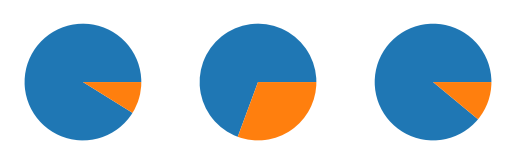

In [39]:
# Building the 3 different Pie Plots
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts())

plt.show()

- What we get back is pretty good!
    - It's not the best..., but it's not the worst either!
- We got back 3 Pie Charts! They may be right, they may not be right, we gotta actually update it!
- So we will need to first off Add in the Titles for these Pie Charts, then do some more Cleanup of adding in the Percentage Values and cleaning the position of the Slices
    - We actually haven't used the `title` Variable yet, so we can utilize it and Set the Titles for all 3 Pie Charts
        - To do this:
        - We are already cycling through the different **Indexes** and we provide the appropriate `ax` via the bracket notation `[]`, in this case `i`
        - Putting it all together we get `ax[i]`
        - Then invoking the `.set_title()` Function
        - Passing in the `title` Variable in here
    - Now this will assign the correct Title to the correct Pie Chart as it loops through based on the **Index** in `i`

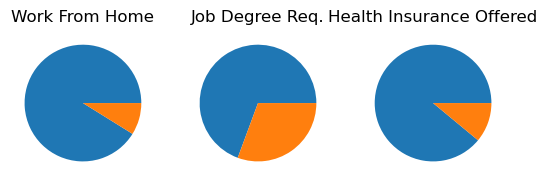

In [42]:
# Adding the Titles to the Pie Charts
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts())
    ax[i].set_title(title)

plt.show()

- Now we have Titles above each of the Pie Charts
- Now we need to work on getting the Values to Display for each of the Pie Charts that show, what portion of the Chart is True/False and what the Numerical Value associated with that Boolean
- TO do this we just need to do what we did earlier
    - First off, fixing the Starting Angle of the Slices
        - Do this by passing `startangle=90` into the `.pie()` Function
    - Next, displaying the Percentage Values as a Float for each of the True/False Slices of the individual Pie Charts
        - Do this by passing `autopct='%1.1f%%'` into the `.pie()` Function

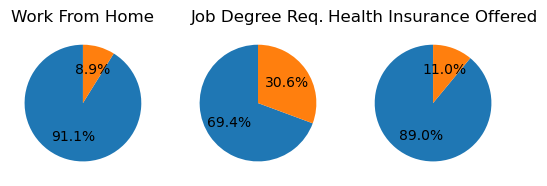

In [43]:
# Displaying the Values associated to the True/False Slices and also changing the Start Angle for the True Slice
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle=90, autopct='%1.1f%%')
    ax[i].set_title(title)

plt.show()

- Now we have Percentage Values appearing for all the Pie Charts, for all the True/False Slices
- And we also have the True Slice fixed and appearing in the Top Center portion for all the Pie Charts
- The only thing we don't know is, which of these Values are True and which are False?
- So there's just one more thing missing from our Cleanup
    - We will need to Pass in 1 more Parameter into our `.pie()` Function
    - And this will be `labels=`
        - We need to Provide a List of `labels` and they have to be Passed in, in the correct order or they will be wrong
        - Specifically, we will Pass in False and True for our case
    - We Set this equals to `['False', 'True']`

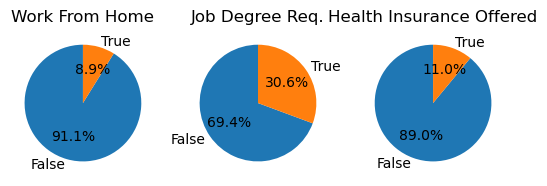

In [44]:
# Adding in Labels to each of the Pie Charts to Display which Slices are True/False
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)

plt.show()

- We now have it Displaying the True/False Labels for each of the Slices, for each of the Pie Charts
- We now have our Final Visualization using Loops in order to enumerate through and Graph everything and we don't have to write repetitive Code